In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
mne.set_log_level('error')
import warnings
warnings.simplefilter("ignore")

In [178]:
df = pd.read_csv('EEGdata.csv')
df

,Time,FZ,C3,CZ,C4,PZ,PO7,OZ,PO8,AccX,AccY,AccZ,Gyro1,Gyro2,Gyro3,Battery,Counter,Validation
0,471108.629297,259145.062500,255463.203125,280156.78125,297592.40625,268555.25000,255108.156250,232334.953125,239896.906250,-0.156006,0.782959,-0.566162,-10.437011,6.835937,13.610839,93.333344,405287.0,1.0
1,471108.634537,259071.937500,255626.625000,282968.28125,297913.18750,269795.59375,255109.765625,232506.515625,240036.203125,-0.143799,0.778809,-0.562500,-9.582519,6.866455,13.305663,93.333344,405288.0,1.0
2,471108.634549,259450.296875,255598.296875,283131.25000,297802.50000,269435.43750,255080.796875,232323.593750,239907.625000,-0.137451,0.773926,-0.560303,-9.185790,7.019042,13.183593,93.333344,405289.0,1.0
3,471108.636824,259770.734375,255431.093750,280456.65625,297436.09375,267998.68750,255079.453125,232064.765625,239711.656250,-0.133545,0.770508,-0.560303,-8.483886,7.385253,12.847899,93.333344,405290.0,1.0
4,471108.639355,259562.062500,255346.515625,278669.31250,297312.09375,267488.87500,255097.703125,232085.765625,239713.000000,-0.132324,0.774902,-0.561523,-7.568359,7.873535,12.390136,93.333344,405291.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22495,471198.551129,258254.125000,254949.640625,279801.21875,295778.25000,268732.00000,254846.203125,232013.718750,238981.109375,-0.112061,0.844971,-0.537354,-0.366211,1.525879,1.220703,93.333344,427782.0,1.0
22496,471198.553541,258417.921875,255122.828125,281468.75000,295981.37500,269351.40625,254852.453125,232079.421875,239042.890625,-0.112549,0.842041,-0.536865,-0.305176,1.434326,1.220703,93.333344,427783.0,1.0
22497,471198.553577,259169.203125,255450.406250,281751.81250,295821.40625,269106.87500,254874.625000,231927.250000,238939.890625,-0.112793,0.843262,-0.536377,-0.335693,1.403808,1.342773,93.333344,427784.0,1.0
22498,471198.556081,259407.296875,255442.984375,280239.21875,295526.37500,268337.25000,254880.078125,231773.296875,238814.281250,-0.109863,0.843994,-0.535156,-0.396728,1.373291,1.342773,93.333344,427785.0,1.0


In [179]:
events_array = df['Validation']
df = df.drop(columns = ['Time','AccX','AccY','AccZ','Gyro1','Gyro2','Gyro3','Battery','Counter','Validation'])
eeg_df = df.values.T * 1e-6  # Convert μV to Volts
ch_names = df.columns.tolist()
ch_types = ['eeg']*len(ch_names)

In [180]:
events_array

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
22495    1.0
22496    1.0
22497    1.0
22498    1.0
22499    1.0
Name: Validation, Length: 22500, dtype: float64

In [16]:
info = mne.create_info(ch_names = ch_names, ch_types = ch_types, sfreq = 250)
raw = mne.io.RawArray(eeg_df, info)
raw

<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>

In [18]:
# raw.drop_channels(['Time','AccX','AccY','AccZ','Gyro1','Gyro2','Gyro3','Battery','Counter','Validation'])

In [19]:
raw.describe()

<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>
ch  name  type  unit        min         Q1     median         Q3        max
 0  FZ    EEG   µV    258186.17  258779.37  259110.16  259337.83  259782.62
 1  C3    EEG   µV    254641.19  255149.62  255247.55  255438.27  255750.28
 2  CZ    EEG   µV    276033.88  279648.48  280666.67  282058.84  284657.62
 3  C4    EEG   µV    295350.25  296175.10  296616.55  297078.41  297941.00
 4  PZ    EEG   µV    266834.34  268176.06  268638.08  269376.92  270314.69
 5  PO7   EEG   µV    254586.30  254895.55  254931.62  254963.95  255142.77
 6  OZ    EEG   µV    231668.16  231855.38  232014.78  232102.67  232609.78
 7  PO8   EEG   µV    238791.30  239002.39  239124.70  239290.30  240071.78


In [20]:
raw.info['dig']

In [21]:
raw.info['ch_names']

['FZ', 'C3', 'CZ', 'C4', 'PZ', 'PO7', 'OZ', 'PO8']

In [22]:
mapping = {
    'FZ': 'Fz',
    'CZ': 'Cz',
    'C3': 'C3',
    'C4': 'C4',
    'PZ': 'Pz',
    'PO7': 'PO7',
    'OZ': 'Oz',
    'PO8': 'PO8'
}

raw.rename_channels(mapping)


<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>

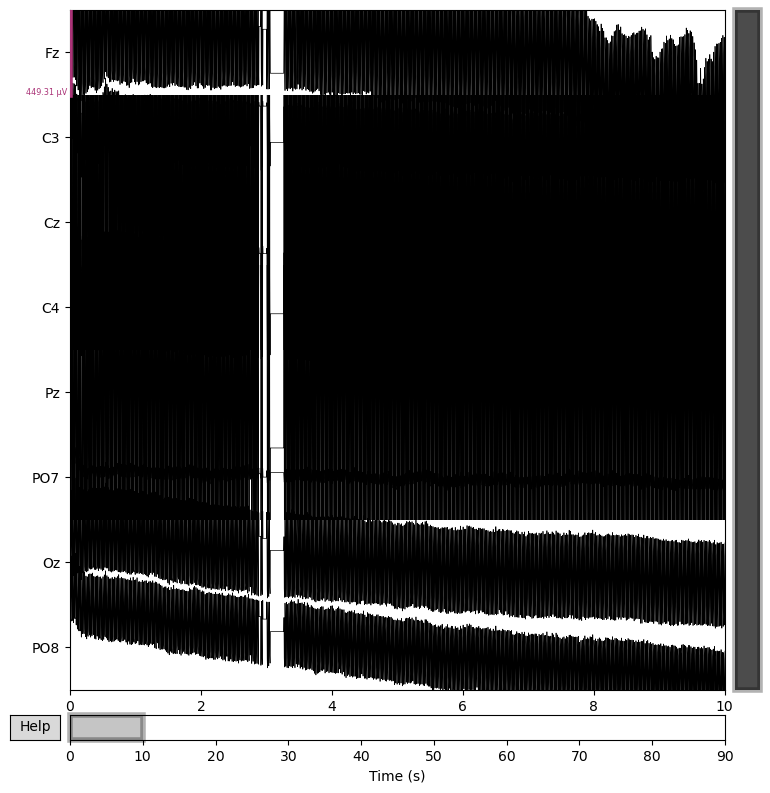

In [23]:
picks = mne.pick_channels_regexp(raw.ch_names, regexp="['FZ', 'C3', 'CZ', 'C4', 'PZ', 'PO7', 'OZ', 'PO8']")
raw.plot(order=picks, n_channels=len(picks), scalings = 'auto');

In [24]:
mne.channels.get_builtin_montages()

['standard_1005',
 'standard_1020',
 'standard_alphabetic',
 'standard_postfixed',
 'standard_prefixed',
 'standard_primed',
 'biosemi16',
 'biosemi32',
 'biosemi64',
 'biosemi128',
 'biosemi160',
 'biosemi256',
 'easycap-M1',
 'easycap-M10',
 'easycap-M43',
 'EGI_256',
 'GSN-HydroCel-32',
 'GSN-HydroCel-64_1.0',
 'GSN-HydroCel-65_1.0',
 'GSN-HydroCel-128',
 'GSN-HydroCel-129',
 'GSN-HydroCel-256',
 'GSN-HydroCel-257',
 'mgh60',
 'mgh70',
 'artinis-octamon',
 'artinis-brite23',
 'brainproducts-RNP-BA-128']

In [25]:
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>

In [27]:
# raw.drop_channels(['Acc_norm', 'gyro_norm', 'Validation'])

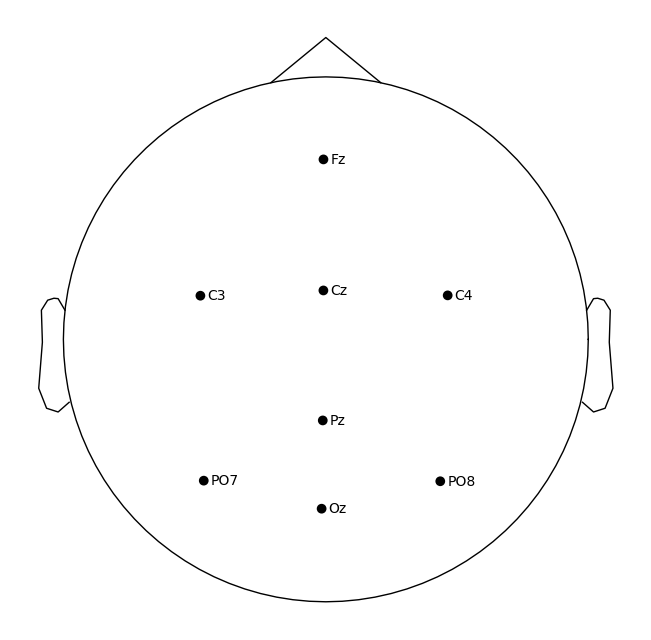

In [28]:
raw.plot_sensors(show_names = True)
plt.show()

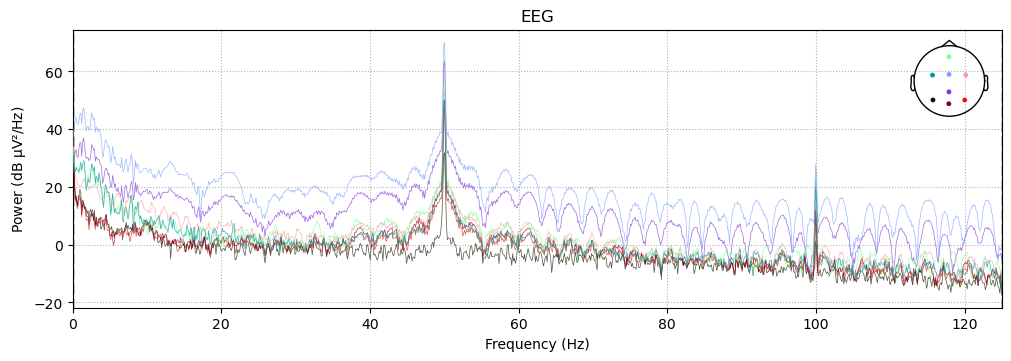

In [29]:
psd = raw.compute_psd()
psd.plot()
plt.show()

In [93]:
low_cut = .1
hig_cut = 30
raw.notch_filter(freqs = 50)
raw_filt = raw.copy().filter(low_cut, hig_cut)

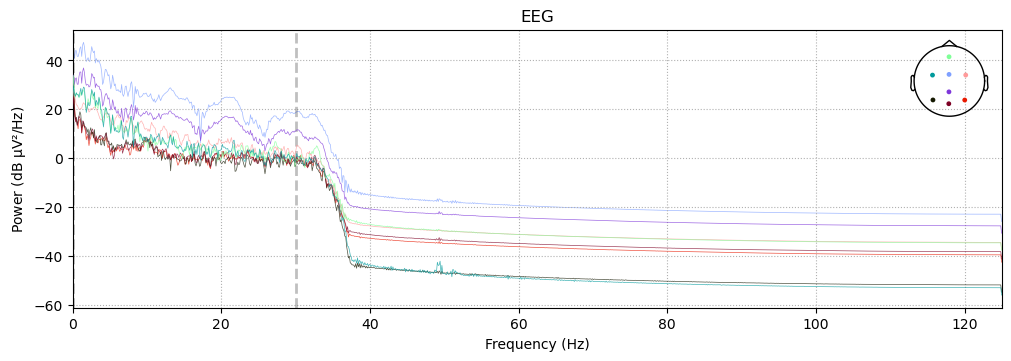

In [94]:
raw_filt.compute_psd().plot()

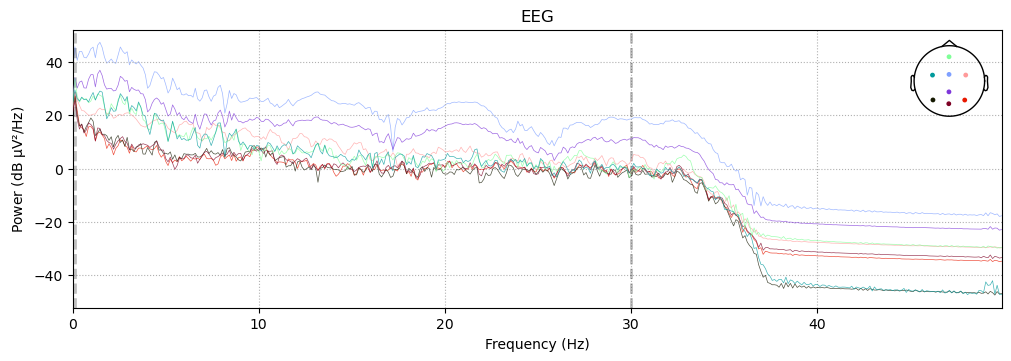

In [95]:
raw_filt.compute_psd(fmax=50).plot()

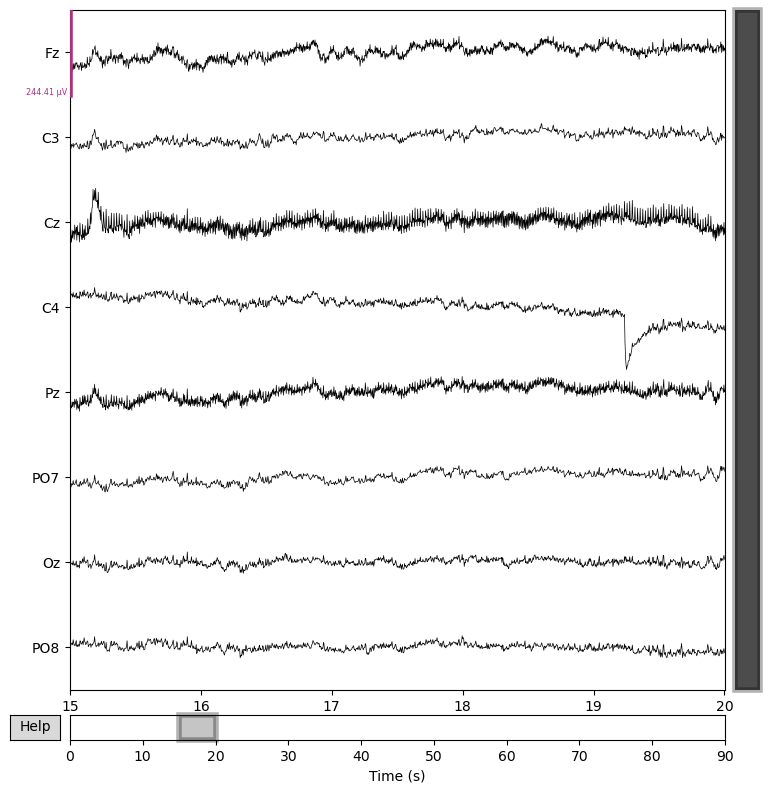

In [101]:
raw.plot(start = 15, duration = 5, scalings = "auto");

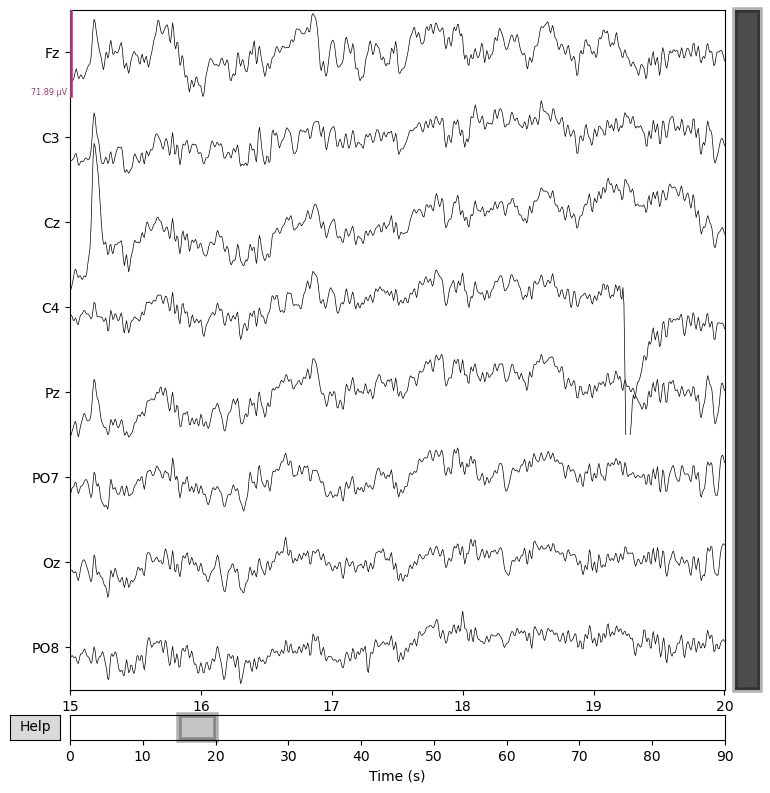

In [102]:
raw_filt.plot(start = 15, duration = 5, scalings = 'auto');

In [103]:
# Break raw data into 1 s epochs
tstep = 1.0
events_ica = mne.make_fixed_length_events(raw_filt, duration=tstep)
epochs_ica = mne.Epochs(raw_filt, events_ica,
                        tmin=0.0, tmax=tstep,
                        baseline=None,
                        preload=True)

In [68]:
!pip install autoreject

In [104]:
from autoreject import AutoReject

ar = AutoReject(n_interpolate=[1, 2, 4],
                random_state=42,
                picks=mne.pick_types(epochs_ica.info, 
                                     eeg=True,
                                     eog=False
                                    ),
                n_jobs=-1, 
                verbose=False
                )

ar.fit(epochs_ica)

reject_log = ar.get_reject_log(epochs_ica)

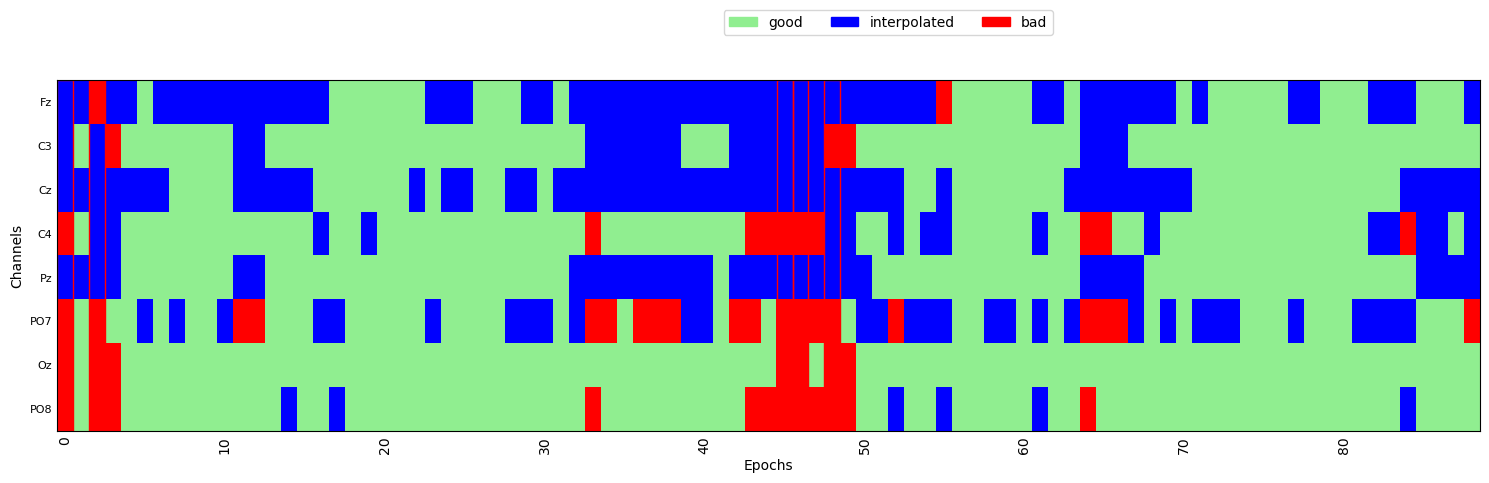

In [105]:

fig, ax = plt.subplots(figsize=[15, 5])
reject_log.plot('horizontal', ax=ax, aspect='auto')
plt.show()

In [138]:
# ICA parameters
random_state = 42   # ensures ICA is reproducible each time it's run
ica_n_components = .99     # Specify n_components as a decimal to set % explained variance

# Fit ICA
ica = mne.preprocessing.ICA(n_components=ica_n_components,
                            random_state=random_state,
                            )
ica.fit(epochs_ica[~reject_log.bad_epochs], decim=3)

Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,11 iterations on epochs (7056 samples)
ICA components,4
Available PCA components,8
Channel types,eeg
ICA components marked for exclusion,—


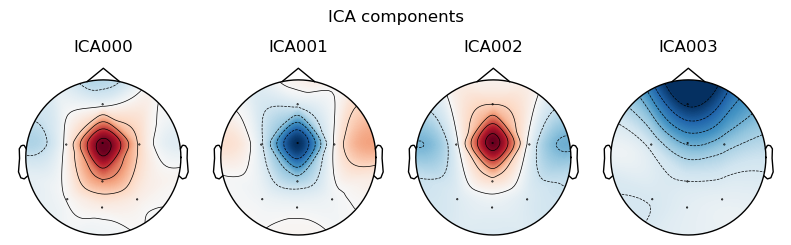

In [139]:
ica.plot_components();

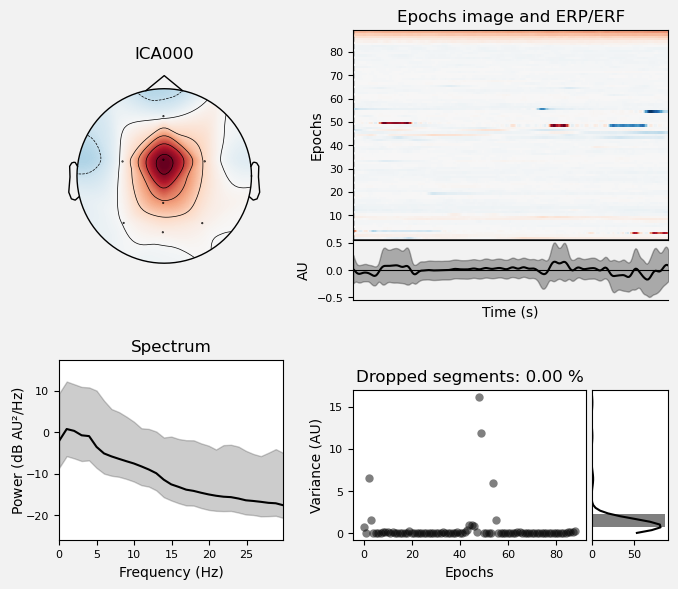

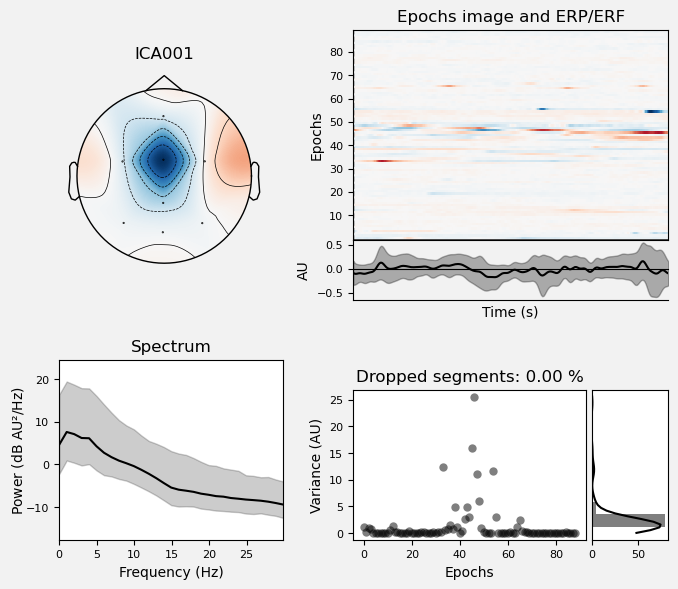

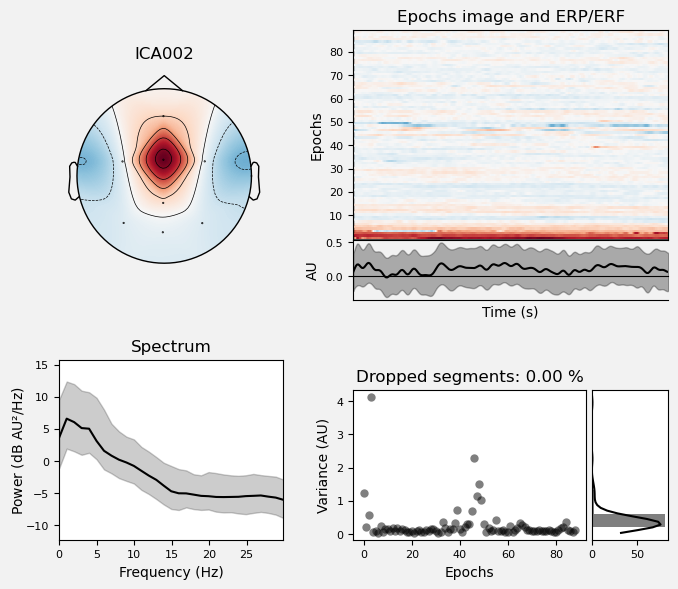

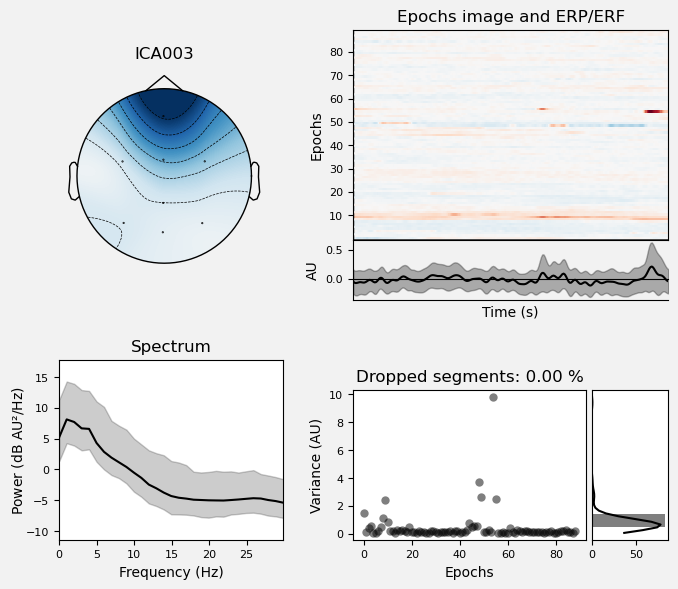

In [120]:
ica.plot_properties(epochs_ica, picks=range(0, ica.n_components_), psd_args={'fmax': hig_cut});

In [140]:
ica.exclude = []
num_excl = 0
max_ic = 2
z_thresh = 3.5
z_step = .05

while num_excl < max_ic:
    eog_indices, eog_scores = ica.find_bads_eog(epochs_ica,
                                                ch_name=['Fz'], 
                                                threshold=z_thresh
                                                )
    num_excl = len(eog_indices)
    z_thresh -= z_step # won't impact things if num_excl is ≥ n_max_eog 

# assign the bad EOG components to the ICA.exclude attribute so they can be removed later
ica.exclude = eog_indices

print('Final z threshold = ' + str(round(z_thresh, 2)))

Final z threshold = 1.35


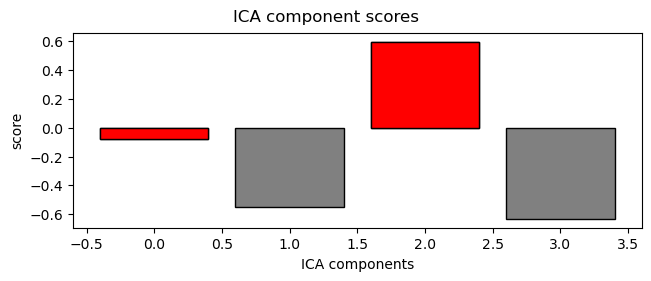

In [141]:
ica.plot_scores(eog_scores);


In [121]:
event_indices = np.where(events_array > 0)[0]
mne_events = np.array([[i, 0, events_array[i]] for i in event_indices])
mne_events = mne_events.astype('int64')
mne_events

array([[    0,     0,     1],
       [    1,     0,     1],
       [    2,     0,     1],
       ...,
       [22497,     0,     1],
       [22498,     0,     1],
       [22499,     0,     1]], dtype=int64)

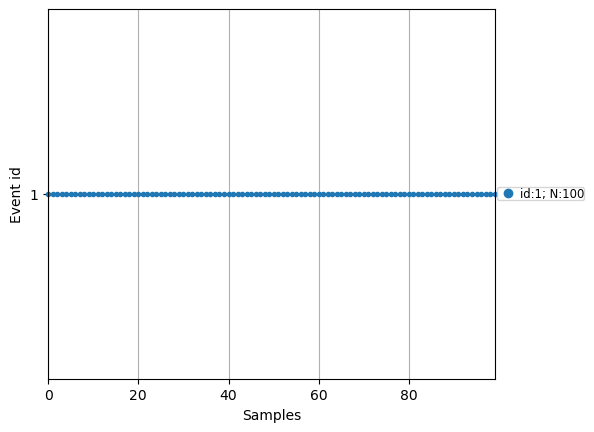

In [110]:
mne.viz.plot_events(mne_events[:100]);

In [ ]:
#raw = mne.io.read_raw_fif('MI_S10_1_10_.fif', preload=True)
#raw

In [ ]:
#events = mne.find_events(raw, stim_channel = 'Validation',consecutive=True, shortest_event=0)
#events

In [ ]:
#events, events_dict = mne.events_from_annotations(raw)
#events

In [114]:
event_ids = {"standard/stimulus":1}
epochs = mne.Epochs(raw_filt, mne_events, event_ids, preload = True)

In [115]:
epochs

<Epochs | 22183 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~238.3 MiB, data loaded,
 'standard/stimulus': 22183>

In [116]:
epochs_postica = ica.apply(epochs.copy())


In [117]:
from autoreject import AutoReject

ar = AutoReject(n_interpolate=[1, 2, 4],
                random_state=42,
                picks=mne.pick_types(epochs_postica.info, 
                                     eeg=True,
                                     eog=False
                                    ),
                n_jobs=-1, 
                verbose=False
                )

epochs_clean, reject_log_clean = ar.fit_transform(epochs_postica, return_log=True)

epochs_clean

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=[10, 4])
reject_log_clean.plot('horizontal', aspect='auto', ax=ax)
plt.show()

In [136]:
print(raw_filt)

<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>


In [137]:
df_filtered = raw_filt.to_data_frame()
df_filtered

,time,Fz,C3,Cz,C4,Pz,PO7,Oz,PO8
0,0.000,0.000000e+00,6.245005e-11,5.551115e-11,4.163336e-11,4.163336e-11,2.081668e-11,4.857226e-11,4.163336e-11
1,0.004,1.618453e+02,2.040761e+01,5.793605e+02,1.284586e+01,6.400622e+01,-6.885390e+00,-4.501545e+01,-2.619350e+01
2,0.008,2.806130e+02,3.513272e+01,1.003952e+03,2.213492e+01,1.105813e+02,-1.190691e+01,-7.721861e+01,-4.546176e+01
3,0.012,3.324977e+02,4.129814e+01,1.187416e+03,2.619786e+01,1.303576e+02,-1.368030e+01,-8.908660e+01,-5.354537e+01
4,0.016,3.222757e+02,4.006089e+01,1.145412e+03,2.603129e+01,1.258753e+02,-1.170346e+01,-8.114956e+01,-5.032949e+01
...,...,...,...,...,...,...,...,...,...
22495,89.980,-3.158406e+01,1.052093e+02,1.799012e+03,2.809543e+02,7.848216e+02,1.092406e-01,1.256945e+02,1.135362e+02
22496,89.984,-3.453366e+01,1.060665e+02,1.850447e+03,2.877456e+02,8.051746e+02,-3.163778e+00,1.266123e+02,1.146498e+02
22497,89.988,-3.020832e+01,8.794288e+01,1.556550e+03,2.411073e+02,6.761297e+02,-4.426559e+00,1.049197e+02,9.517968e+01
22498,89.992,-1.775706e+01,5.018440e+01,8.957310e+02,1.384023e+02,3.887139e+02,-3.100262e+00,5.985469e+01,5.435589e+01


In [191]:
df_filtered['Validation'] = events_array
X = df_filtered.iloc[:,:-1].values
df_filtered['Validation'] = df_filtered['Validation'].astype('int64')
Y = df_filtered.iloc[:,8].values


In [192]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)
print('Trainnig Complete..')

Trainnig Complete..


In [193]:
from sklearn.preprocessing import StandardScaler
SC_X = StandardScaler()
X_train = SC_X.fit_transform(X_train)
X_test = SC_X.transform(X_test)
SC_Y = StandardScaler()


In [194]:
from sklearn.svm import SVR
classifier = SVR(kernel = 'rbf')
classifier.fit(X_train, y_train)


SVR()

In [195]:
y_pred = classifier.predict(X_test)

In [196]:
df = pd.DataFrame({"Actual": y_test,
                  "Prediction":y_pred})
df.head(10)

,Actual,Prediction
0,-9.827169,-9.812356
1,12.392709,12.524945
2,14.455185,14.530966
3,26.714800,26.786350
4,1.778545,1.685874
5,-12.382313,-12.321865
6,21.485328,21.476545
7,2.454660,2.465455
8,-15.954261,-16.023732
9,-5.413159,-5.526853


In [197]:
y_test = np.round(y_test).astype(int)
y_pred = np.round(y_pred).astype(int)


In [198]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [199]:
import seaborn as sns
plt.figure(figsize = (10,8))
sns.heatmap(cm, annot = True, cmap = "Greens")

<Axes: >

In [200]:
accuracy_score(y_test, y_pred)

0.7312